In [ ]:
# Uncomment these in a fresh notebook environment.
#%pip install -r ../requirements.txt
#%pip install -e ..

## Generate the SUMO simulation files

This default setup is a small `4x4` grid with four traffic-light agents. Change these values first for a different learning problem.


In [2]:
#%reload_ext autoreload
#%autoreload 2

from marl_tsc.simulation_generator import SimulationGenerator, DEFAULT_TRAFFIC_LIGHT_IDS
from marl_tsc.training import train_ppo, evaluate_policy, plot_training_histories, plot_moving_average_histories
from marl_tsc.mappo import train_mappo
from marl_tsc.baselines import random_actions, fixed_time_actions

from marl_tsc.graph_based.train_graph_mappo import train_graph_mappo
from marl_tsc.graph_based.train_true_mappo import train_true_mappo
from marl_tsc.graph_based.graph_policy_adapter import GraphPolicyAdapter
from marl_tsc.graph_based.graph_builder import GraphBuilder

from pathlib import Path
import matplotlib.pyplot as plt

GREEN_PHASE_COUNT = None  # Let SUMO/network discovery choose the phase count.
NOTEBOOK_DIR = Path.cwd().resolve()
PROJECT_ROOT = NOTEBOOK_DIR.parent if (NOTEBOOK_DIR / "main_flow.ipynb").exists() else NOTEBOOK_DIR
#OUTPUT_DIR = PROJECT_ROOT / "outputs"#commented out for colab redirection

traffic_light_ids = list(DEFAULT_TRAFFIC_LIGHT_IDS)

In [3]:
EPISODE_STEPS = 600
SECONDS_PER_ACTION = 5
SIMULATION_DURATION = EPISODE_STEPS * SECONDS_PER_ACTION

# Keep vehicles entering slightly longer than the episode runs.
TRAFFIC_SPAWN_DURATION = int(SIMULATION_DURATION * 1.20)

EVALUATION_EPISODES = 3
TOTAL_TIMESTEPS = 200_000
MIN_GREEN_SECONDS = 10
SWITCH_PENALTY = 0.5

generator = SimulationGenerator(
    output_dir=OUTPUT_DIR,
    grid_number=4,
    lane_number=2,
    traffic_light_ids=traffic_light_ids,
    trip_begin=0,
    trip_end=TRAFFIC_SPAWN_DURATION,
    trip_period=2,
    seed=42,
)

paths = generator.generate_all()
print(f"Generated SUMO config: {paths.config_file}")
print(f"Simulation horizon: {SIMULATION_DURATION}s")
print(f"Traffic spawn duration: {TRAFFIC_SPAWN_DURATION}s")
print("Traffic-light agents:", traffic_light_ids)

Generated SUMO config: /content/drive/MyDrive/Uni-Masters/Group Project/outputs/config.sumocfg
Simulation horizon: 3000s
Traffic spawn duration: 3600s
Traffic-light agents: ['B1', 'B2', 'C1', 'C2']


## Train

PPO uses parameter sharing through the PettingZoo/SuperSuit/SB3 wrapper. MAPPO adds a centralized critic and a shared decentralized actor.

### PPO

Gym has been unmaintained since 2022 and does not support NumPy 2.0 amongst other critical functionality.
Please upgrade to Gymnasium, the maintained drop-in replacement of Gym, or contact the authors of your software and request that they upgrade.
See the migration guide at https://gymnasium.farama.org/introduction/migration_guide/ for additional information.


 Retrying in 1 seconds


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


 Retrying in 1 seconds


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/stable_baselines3/common/on_policy_algorithm.py:150: UserWarning: You are trying to run PPO on the GPU, but it is primarily intended to run on the CPU when not using a CNN policy (you are using ActorCriticPolicy which should be a MlpPolicy). See https://github.com/DLR-RM/stable-baselines3/issues/1245 for more info. You can pass `device='cpu'` or `export CUDA_VISIBLE_DEVICES=` to force using the CPU.Note: The model will train, but the GPU utilization will be poor and the training might take longer than on CPU.
  warnings.warn(


...

[PPO] Step 194400 | Episode Return: -43.59
[PPO] Step 194400 | Episode Return: -44.81
[PPO] Step 194400 | Episode Return: -45.52
[PPO] Step 194400 | Episode Return: -44.00
 Retrying in 1 seconds


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


[PPO] Step 196800 | Episode Return: -44.21
[PPO] Step 196800 | Episode Return: -43.80
[PPO] Step 196800 | Episode Return: -45.29
[PPO] Step 196800 | Episode Return: -43.90
 Retrying in 1 seconds


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


[PPO] Step 199200 | Episode Return: -43.65
[PPO] Step 199200 | Episode Return: -48.00
[PPO] Step 199200 | Episode Return: -40.26
[PPO] Step 199200 | Episode Return: -44.15


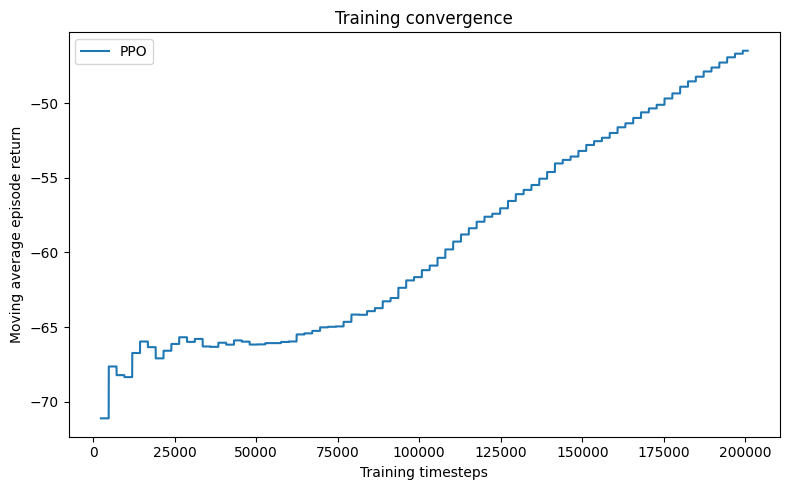

In [ ]:
ppo_model, ppo_history, ppo_model_path = train_ppo(
    config_file=paths.config_file,
    traffic_light_ids=traffic_light_ids,
    output_dir=OUTPUT_DIR,
    total_timesteps=TOTAL_TIMESTEPS,
    max_steps=EPISODE_STEPS,
    seed=42,
    env_kwargs={
        "green_phase_count": GREEN_PHASE_COUNT,
        "min_green_seconds": MIN_GREEN_SECONDS,
        "seconds_per_action": SECONDS_PER_ACTION,
        "switch_penalty": SWITCH_PENALTY,
    },
)

fig, ax = plot_training_histories(ppo_history)
plt.show()

### MAPPO

 Retrying in 1 seconds


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


 Retrying in 1 seconds


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


[MAPPO] Episode 1 | Return: -64.19 | Total Steps: 600
 Retrying in 1 seconds


...

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


[MAPPO] Episode 332 | Return: -35.11 | Total Steps: 199200
 Retrying in 1 seconds


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


[MAPPO] Episode 333 | Return: -35.29 | Total Steps: 199800
 Retrying in 1 seconds


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


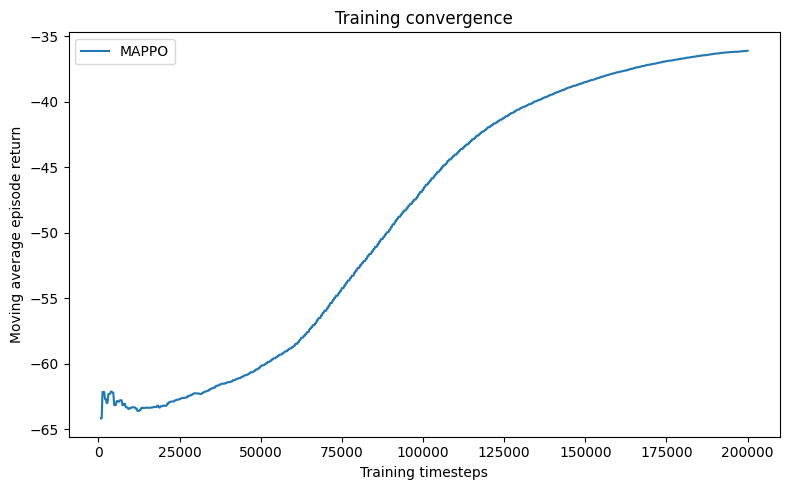

In [ ]:
mappo_model, mappo_history, mappo_model_path = train_mappo(
    config_file=paths.config_file,
    traffic_light_ids=traffic_light_ids,
    output_dir=OUTPUT_DIR,
    total_timesteps=TOTAL_TIMESTEPS,
    rollout_steps=256,
    max_steps=EPISODE_STEPS,
    seed=42,
    env_kwargs={
        "green_phase_count": GREEN_PHASE_COUNT,
        "min_green_seconds": MIN_GREEN_SECONDS,
        "seconds_per_action": SECONDS_PER_ACTION,
        "switch_penalty": SWITCH_PENALTY,
    },
)

fig, ax = plot_training_histories(mappo_history)
plt.show()

### Graph-Based MAPPO

In [ ]:
paths = generator.generate_all()

In [ ]:
map_gat_model, map_gat_history, map_gat_model_path = train_true_mappo(
    config_file=paths.config_file,
    network_file=paths.network_file,
    traffic_light_ids=["B1", "B2", "C1", "C2"],
    output_dir=OUTPUT_DIR,
    clip_ratio=0.2,
    entropy_coef=0.03,
    update_epochs=3,
    total_timesteps=TOTAL_TIMESTEPS,
    rollout_steps=256,
    #hidden_dim=128,
    #critic_hidden_dim=256,
    max_steps=EPISODE_STEPS,
    seed=42,

    env_kwargs={
      "green_phase_count": GREEN_PHASE_COUNT,
      "min_green_seconds": MIN_GREEN_SECONDS,
      "seconds_per_action": SECONDS_PER_ACTION,
      "switch_penalty": SWITCH_PENALTY,
    },
)

 Retrying in 1 seconds
 Retrying in 1 seconds
 Retrying in 1 seconds
 Retrying in 1 seconds
 Retrying in 1 seconds
 Retrying in 1 seconds
 Retrying in 1 seconds
Iter  10 | Actor 0.0495 | Critic 0.0621
 Retrying in 1 seconds
 Retrying in 1 seconds
 Retrying in 1 seconds
Iter  20 | Actor 0.0086 | Critic 0.0747
 Retrying in 1 seconds
 Retrying in 1 seconds
 Retrying in 1 seconds
 Retrying in 1 seconds
Iter  30 | Actor 0.0170 | Critic 1.0768
 Retrying in 1 seconds
 Retrying in 1 seconds
 Retrying in 1 seconds
Iter  40 | Actor 0.0012 | Critic 1.3973
 Retrying in 1 seconds
 Retrying in 1 seconds
 Retrying in 1 seconds
Iter  50 | Actor -0.0002 | Critic 0.2263
 Retrying in 1 seconds
 Retrying in 1 seconds
 Retrying in 1 seconds
Iter  60 | Actor 0.0026 | Critic 0.1293
 Retrying in 1 seconds
 Retrying in 1 seconds
 Retrying in 1 seconds
Iter  70 | Actor -0.0104 | Critic 0.0509
 Retrying in 1 seconds
 Retrying in 1 seconds
 Retrying in 1 seconds
 Retrying in 1 seconds
Iter  80 | Actor 0.0046 | Cr

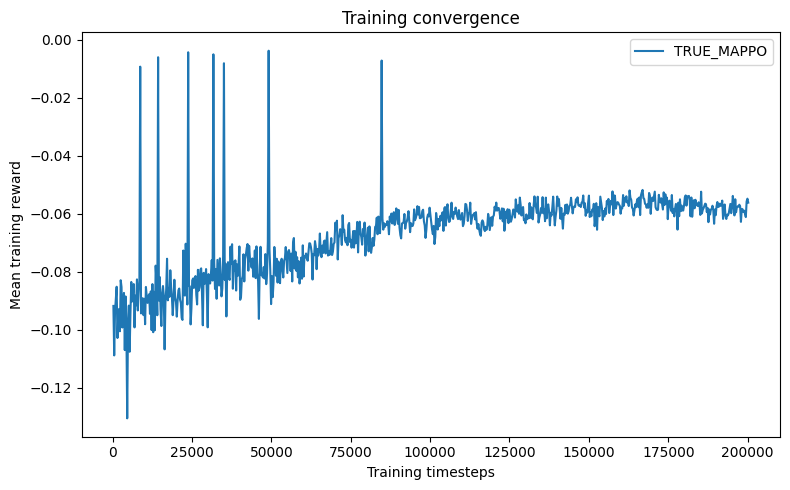

In [ ]:
fig, ax = plot_training_histories(map_gat_history)
plt.show()

(<Figure size 1000x600 with 1 Axes>,
 <Axes: title={'center': 'Training Performance (100-pt Moving Average)'}, xlabel='Timesteps', ylabel='Reward'>)

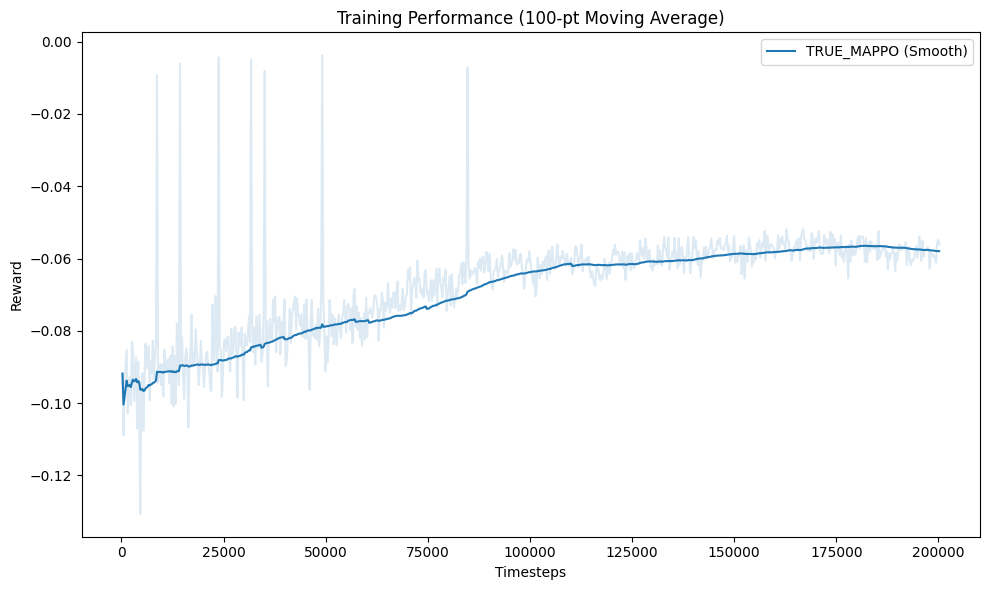

In [ ]:
plot_moving_average_histories(map_gat_history)

In [ ]:
reward_share_pg_model, reward_share_pg_history, reward_share_pg_model_path = train_true_mappo(
    config_file=paths.config_file,
    network_file=paths.network_file,
    traffic_light_ids=["B1", "B2", "C1", "C2"],
    output_dir=OUTPUT_DIR,
    clip_ratio=0.2,
    entropy_coef=0.03,
    update_epochs=3,
    total_timesteps=TOTAL_TIMESTEPS,
    rollout_steps=256,
    max_steps=EPISODE_STEPS,
    reward_sharing="public_goods",
)

 Retrying in 1 seconds
 Retrying in 1 seconds
 Retrying in 1 seconds
 Retrying in 1 seconds
 Retrying in 1 seconds
 Retrying in 1 seconds
 Retrying in 1 seconds
Iter  10 | Actor 0.0305 | Critic 0.0871
 Retrying in 1 seconds
 Retrying in 1 seconds
 Retrying in 1 seconds
Iter  20 | Actor 0.0078 | Critic 0.0790
 Retrying in 1 seconds
 Retrying in 1 seconds
 Retrying in 1 seconds
 Retrying in 1 seconds
Iter  30 | Actor 0.0141 | Critic 0.0680
 Retrying in 1 seconds
 Retrying in 1 seconds
 Retrying in 1 seconds
Iter  40 | Actor -0.0024 | Critic 0.0749
 Retrying in 1 seconds
 Retrying in 1 seconds
 Retrying in 1 seconds
Iter  50 | Actor 0.0022 | Critic 0.0448
 Retrying in 1 seconds
 Retrying in 1 seconds
 Retrying in 1 seconds
Iter  60 | Actor -0.0009 | Critic 0.0272
 Retrying in 1 seconds
 Retrying in 1 seconds
 Retrying in 1 seconds
 Retrying in 1 seconds
Iter  70 | Actor 0.0002 | Critic 0.1635
 Retrying in 1 seconds
 Retrying in 1 seconds
 Retrying in 1 seconds
Iter  80 | Actor -0.0132 | C

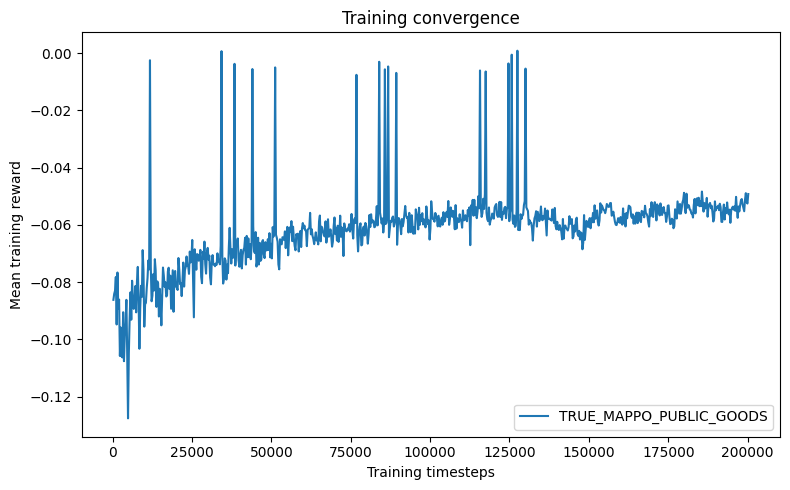

In [ ]:
plot_training_histories(reward_share_pg_history)
plt.show()

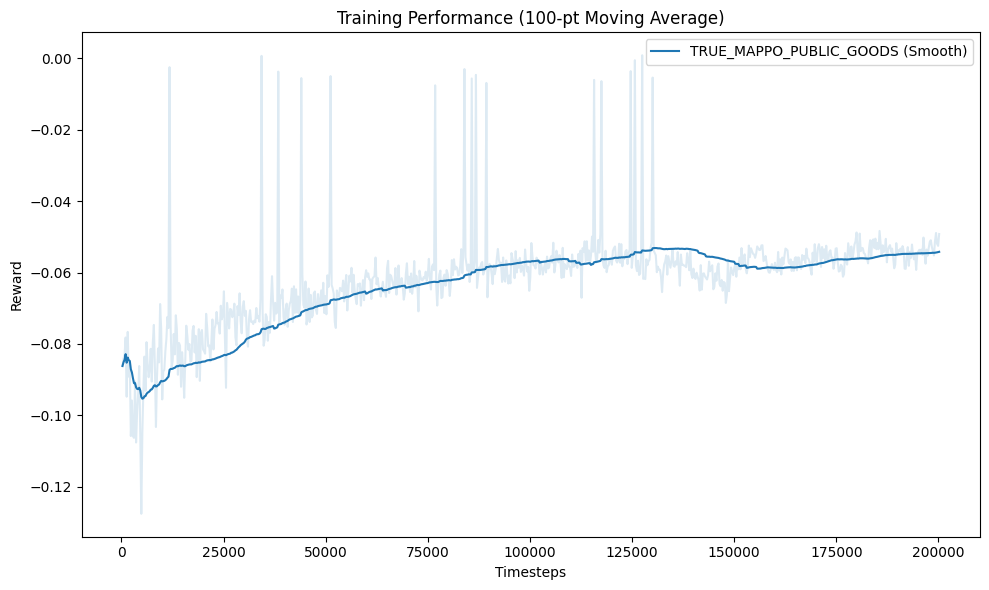

In [ ]:
plot_moving_average_histories(reward_share_pg_history)
plt.show()

In [ ]:
reward_share_zs_model, reward_share_zs_history, reward_share_zs_model_path = train_true_mappo(
    config_file=paths.config_file,
    network_file=paths.network_file,
    traffic_light_ids=["B1", "B2", "C1", "C2"],
    output_dir=OUTPUT_DIR,
    clip_ratio=0.2,
    entropy_coef=0.03,
    update_epochs=3,
    total_timesteps=TOTAL_TIMESTEPS,
    rollout_steps=256,
    max_steps=EPISODE_STEPS,
    reward_sharing="zero_sum",
)

 Retrying in 1 seconds
 Retrying in 1 seconds
 Retrying in 1 seconds
 Retrying in 1 seconds
 Retrying in 1 seconds
 Retrying in 1 seconds
 Retrying in 1 seconds
Iter  10 | Actor 0.0322 | Critic 0.0401
 Retrying in 1 seconds
 Retrying in 1 seconds
 Retrying in 1 seconds
Iter  20 | Actor 0.0183 | Critic 0.0298
 Retrying in 1 seconds
 Retrying in 1 seconds
 Retrying in 1 seconds
Iter  30 | Actor 0.0204 | Critic 0.0216
 Retrying in 1 seconds
 Retrying in 1 seconds
 Retrying in 1 seconds
 Retrying in 1 seconds
Iter  40 | Actor 0.0065 | Critic 0.1224
 Retrying in 1 seconds
 Retrying in 1 seconds
 Retrying in 1 seconds
Iter  50 | Actor 0.0089 | Critic 0.0405
 Retrying in 1 seconds
 Retrying in 1 seconds
 Retrying in 1 seconds
Iter  60 | Actor 0.0029 | Critic 0.0580
 Retrying in 1 seconds
 Retrying in 1 seconds
 Retrying in 1 seconds
 Retrying in 1 seconds
Iter  70 | Actor 0.0045 | Critic 0.0945
 Retrying in 1 seconds
 Retrying in 1 seconds
 Retrying in 1 seconds
Iter  80 | Actor -0.0069 | Cri

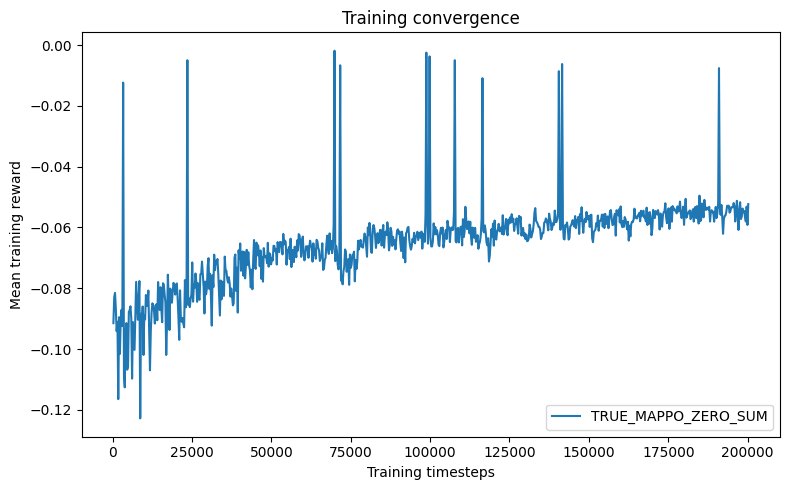

In [ ]:
plot_training_histories(reward_share_zs_history)
plt.show()

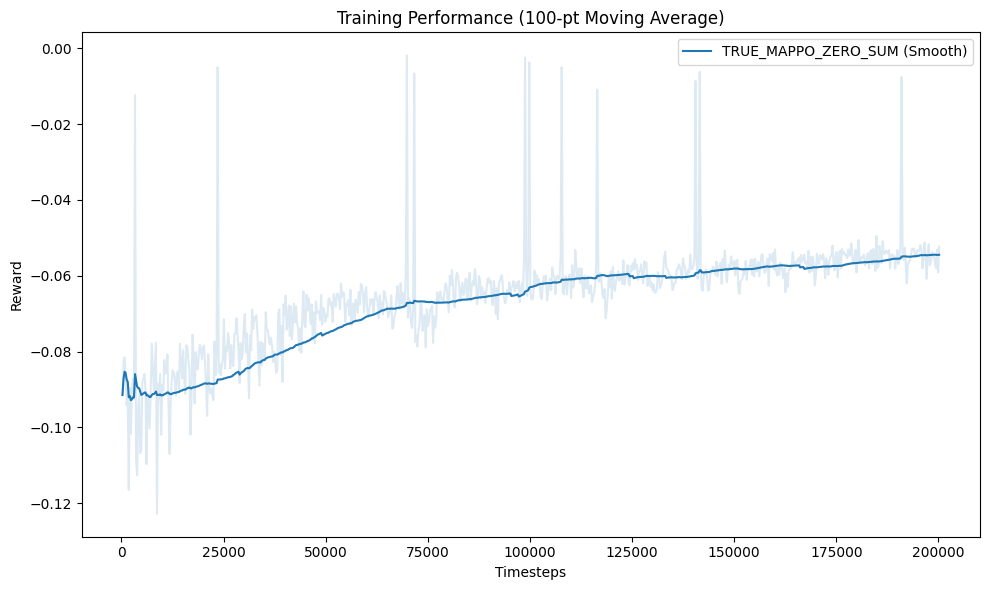

In [ ]:
plot_moving_average_histories(reward_share_zs_history)
plt.show()

In [ ]:
from marl_tsc.graph_based.graph_builder import GraphBuilder

builder = GraphBuilder(paths.network_file)
topology = builder.build()

In [ ]:
graph_mappo_policy = GraphPolicyAdapter(
    graph_policy= map_gat_model,
    topology=topology,
    policy_name="map_gat_mappo",
)

In [ ]:
pg_mappo_policy = GraphPolicyAdapter(
    graph_policy= reward_share_pg_model,
    topology=topology,
    policy_name="pg_mappo",
)

In [ ]:
zs_mappo_policy = GraphPolicyAdapter(
    graph_policy= reward_share_zs_model,
    topology=topology,
    policy_name="zs_mappo",
)

## Heterogenous Graph-Based

In [4]:
# ── SUMO environment ──────────────────────────────────────────────────────────
import shutil
from sumolib.net import readNet

EPISODE_STEPS       = 1000
SECONDS_PER_ACTION  = 5
SIMULATION_DURATION = EPISODE_STEPS * SECONDS_PER_ACTION
TRAFFIC_SPAWN_DURATION = int(SIMULATION_DURATION * 1.20)
TOTAL_TIMESTEPS     = 200_000

network_file_name = "lancasterv2.net.xml"
#network_file_name = "lancaster_373m_35.net.xml"
net_path_in_output = Path(OUTPUT_DIR) / network_file_name

# Copy network file to output dir if needed
for p in [
    Path('/content') / network_file_name,
    Path('/content/marl-tsc/networks') / network_file_name,
    Path.cwd() / network_file_name,
]:
    if p.exists() and p.resolve() != net_path_in_output.resolve():
        shutil.copy2(p, net_path_in_output)
        print(f"Copied network file to {net_path_in_output}")
        break

# Read TLS IDs from network
net = readNet(str(net_path_in_output))
traffic_light_ids = sorted(tls.getID() for tls in net.getTrafficLights())
print(f"Found {len(traffic_light_ids)} traffic lights: {traffic_light_ids}")

# ── Generate demand and config ────────────────────────────────────────────────
vtypes_content = """<additional>
    <vType id="car" vClass="passenger" speedFactor="normc(1,0.1,0.2,2)"  length="4.5" maxSpeed="50"/>
    <vType id="van" vClass="delivery"  speedFactor="normc(0.9,0.1,0.2,2)" length="6.0" maxSpeed="40"/>
    <vType id="bus" vClass="bus"       speedFactor="normc(0.85,0.05,0.2,2)" length="12.0" maxSpeed="30"/>
</additional>"""
vtypes_file = Path(OUTPUT_DIR) / "vtypes.xml"
vtypes_file.write_text(vtypes_content)

'''generator = SimulationGenerator(
    output_dir=OUTPUT_DIR,
    network_filename=network_file_name,
    traffic_light_ids=traffic_light_ids,  # now read from net, not hardcoded
    trip_fringe_factor=10,
    allow_fringe=True,
    trip_period=1.5,
    min_distance=200,
    vtypes_file=vtypes_file,
)'''

generator = SimulationGenerator(
    output_dir=OUTPUT_DIR,
    network_filename=network_file_name,
    traffic_light_ids=traffic_light_ids,
    trip_fringe_factor=10,
    allow_fringe=True,
    trip_period=1.5,
    seed=42,
)
generator.generate_trips()
generator.generate_config()
paths = generator.paths
'''generator.generate_peak_trips(
    peak_end=int(SIMULATION_DURATION * 0.4),
    peak_period=1.0,
    offpeak_period=3.5,
)'''
generator.generate_config()

paths = generator.paths
print(f"Scenario configured: {paths.config_file}")
print(f"Simulation duration: {SIMULATION_DURATION}s")

Copied network file to /content/drive/MyDrive/Uni-Masters/Group Project/outputs/lancasterv2.net.xml
Found 9 traffic lights: ['5464450922', 'cluster_1111602959_6308330_6398665769_6398666101', 'cluster_1395459938_3904465077_6288784963', 'cluster_1671362532_2217405_253943174_3904937313_#3more', 'cluster_2217373_5464742560_610595545_6288784968_#6more', 'cluster_27212021_5464547758_6299153326', 'joinedS_3903073405_cluster_5835265011_610595547', 'joinedS_6528610881_cluster_1305014216_5464547754_6100910_6528610880_cluster_2217469_5464547745_5464547748_5464547749', 'joinedS_cluster_1670999797_1670999973_2217366_3903086088_#1more_cluster_1670999799_2217365_6308327']
Scenario configured: /content/drive/MyDrive/Uni-Masters/Group Project/outputs/config.sumocfg
Simulation duration: 5000s


In [5]:
from marl_tsc.graph_based.graph_builder import GraphBuilder

builder = GraphBuilder(paths.network_file)

topology = builder.build()
print("Topology output:")
print("List of Nodes")
print(topology.agent_ids)
print("Edge Index:Columns Represent source --> Target")
print(topology.edge_index)

Topology output:
List of Nodes
['5464450922', 'cluster_1111602959_6308330_6398665769_6398666101', 'cluster_1395459938_3904465077_6288784963', 'cluster_1671362532_2217405_253943174_3904937313_#3more', 'cluster_2217373_5464742560_610595545_6288784968_#6more', 'cluster_27212021_5464547758_6299153326', 'joinedS_3903073405_cluster_5835265011_610595547', 'joinedS_6528610881_cluster_1305014216_5464547754_6100910_6528610880_cluster_2217469_5464547745_5464547748_5464547749', 'joinedS_cluster_1670999797_1670999973_2217366_3903086088_#1more_cluster_1670999799_2217365_6308327']
Edge Index:Columns Represent source --> Target
tensor([[3, 6, 5, 7, 1, 8, 7, 4],
        [7, 8, 7, 3, 4, 6, 5, 1]])


Reading network: /content/drive/MyDrive/Uni-Masters/Group Project/outputs/lancasterv2.net.xml
Parsing TLS phase info from XML...
Building heterogeneous graph...

INTERSECTION NODES (agents)
  5464450922
    phases=3  actions=1  degree=0  pos=(458.9, 264.9)
  cluster_1111602959_6308330_6398665769_6398666101
    phases=4  actions=2  degree=1  pos=(656.5, 256.6)
  cluster_1395459938_3904465077_6288784963
    phases=4  actions=2  degree=0  pos=(478.7, 718.1)
  cluster_1671362532_2217405_253943174_3904937313_#3more
    phases=3  actions=1  degree=1  pos=(425.5, 332.1)
  cluster_2217373_5464742560_610595545_6288784968_#6more
    phases=6  actions=3  degree=1  pos=(665.6, 349.4)
  cluster_27212021_5464547758_6299153326
    phases=3  actions=1  degree=0  pos=(331.8, 628.4)
  joinedS_3903073405_cluster_5835265011_610595547
    phases=4  actions=2  degree=0  pos=(666.7, 448.2)
  joinedS_6528610881_cluster_1305014216_5464547754_6100910_6528610880_cluster_2217469_5464547745_5464547748_5464547749
 

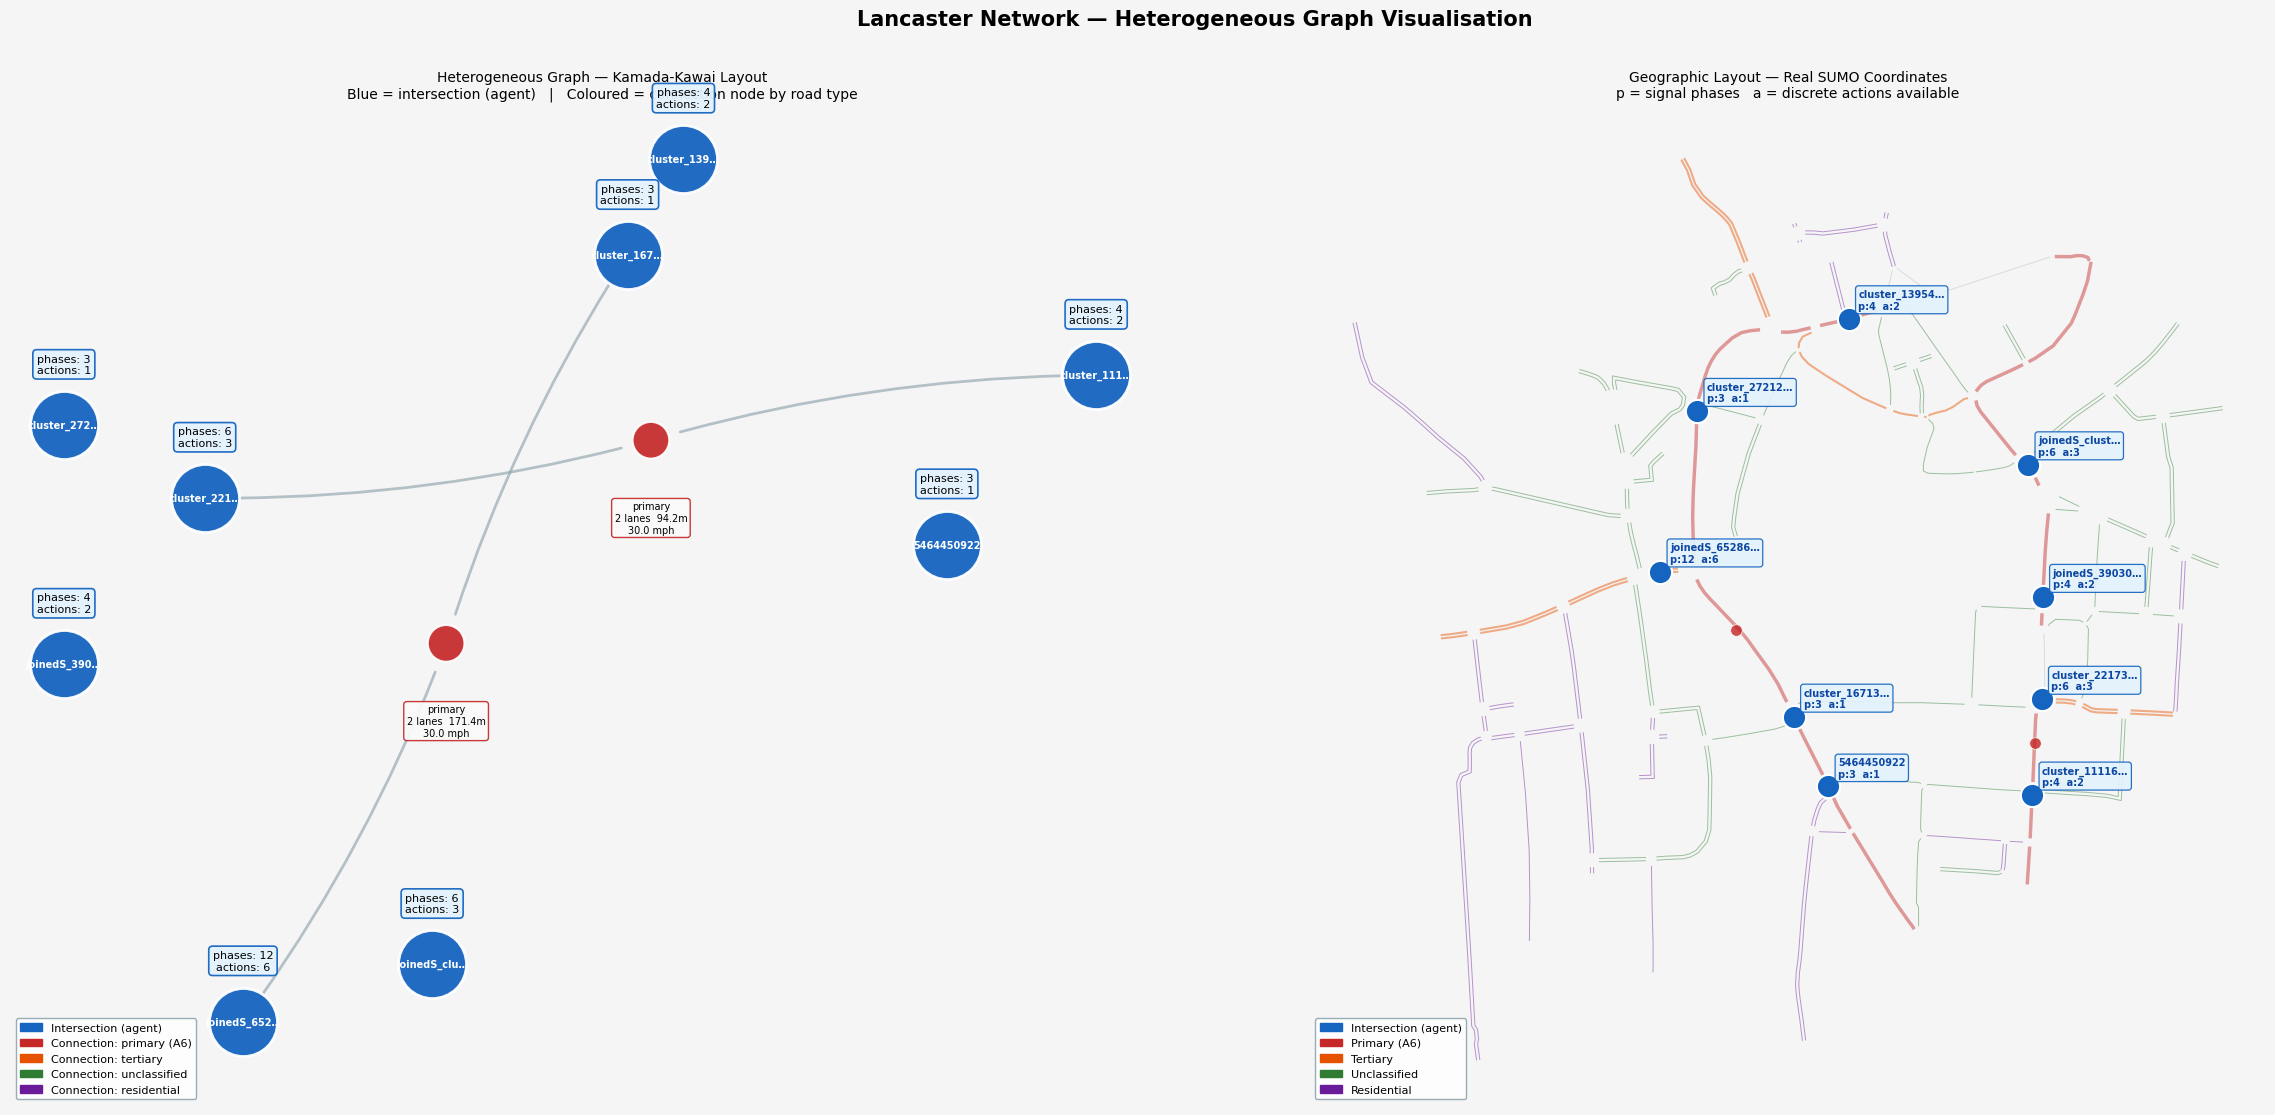

Saved to /content/drive/MyDrive/Uni-Masters/Group Project/outputs/het_network_visualisation.png


In [40]:
#/content/marl-tsc/networks
from networks.visualise_het_net import visualise_het_network

visualise_het_network(
    network_file=str(paths.network_file),
    output_dir=str(OUTPUT_DIR),
    max_hops=1
)

In [7]:
from sumolib.net import readNet

net = readNet(str(paths.network_file))

tls_ids = set(tls.getID() for tls in net.getTrafficLights())

# Check all edges — what TLS IDs are appearing on from/to nodes
tls_id_counts = {}
non_tls_between_tls = []

for edge in net.getEdges():
    fn = edge.getFromNode()
    tn = edge.getToNode()
    f_tls = fn.getTLSID() if fn else ""
    t_tls = tn.getTLSID() if tn else ""

    # Count what TLS IDs appear
    for tid in [f_tls, t_tls]:
        if tid:
            tls_id_counts[tid] = tls_id_counts.get(tid, 0) + 1

    # Find edges where one end is TLS but other isn't
    if (f_tls in tls_ids) and not t_tls:
        non_tls_between_tls.append({
            "edge": edge.getID(),
            "from_tls": f_tls,
            "to_node": tn.getID() if tn else "?",
            "to_node_type": tn.getType() if tn else "?",
            "priority": edge.getPriority(),
            "road_type": edge.getType(),
        })

print(f"TLS IDs seen on edge endpoints: {len(tls_id_counts)}")
print(f"Edges leaving TLS to non-TLS node: {len(non_tls_between_tls)}")
print("\nSample of non-primary edges leaving TLS junctions:")
for e in non_tls_between_tls[:15]:
    if e["priority"] < 12:
        print(f"  {e['from_tls'][:30]} -> {e['to_node']} "
              f"(type={e['road_type']} priority={e['priority']})")

TLS IDs seen on edge endpoints: 9
Edges leaving TLS to non-TLS node: 20

Sample of non-primary edges leaving TLS junctions:
  cluster_2217373_5464742560_610 -> 3471987091 (type=highway.tertiary priority=10)
  joinedS_6528610881_cluster_130 -> 5464547753 (type=highway.tertiary priority=10)
  joinedS_6528610881_cluster_130 -> 349176486 (type=highway.unclassified priority=4)
  cluster_1395459938_3904465077_ -> 1395459952 (type=highway.residential priority=3)
  cluster_27212021_5464547758_62 -> 6308324 (type=highway.unclassified priority=4)
  cluster_1671362532_2217405_253 -> 253943173 (type=highway.unclassified priority=4)
  joinedS_6528610881_cluster_130 -> 253943175 (type=highway.tertiary priority=10)
  joinedS_6528610881_cluster_130 -> 27210812 (type=highway.unclassified priority=4)
  joinedS_cluster_1670999797_167 -> 610595563 (type=highway.unclassified priority=4)
  cluster_1671362532_2217405_253 -> 610595529 (type=highway.unclassified priority=4)
  cluster_1111602959_6308330_639 -> 

In [8]:
from marl_tsc.graph_based.heterogene.hetero_graph_env import HeteroGraphEnv

def print_action_spaces(network_file, config_file, traffic_light_ids):
    """Inspect action spaces for all agents without running training."""
    env = HeteroGraphEnv(
        config_file=str(config_file),
        network_file=str(network_file),
        possible_agents=traffic_light_ids,
        intersection_obs_dim=1,
        shared_dim=1,
    )

    try:
        print("\n" + "=" * 70)
        print("AGENT ACTION SPACES")
        print("=" * 70)

        action_dims = {}
        for agent in env.agent_ids:
            space = env.action_spaces[agent]
            dim = space.n if hasattr(space, 'n') else int(space.nvec[0])
            action_dims[agent] = dim
            short = agent[:40] + "…" if len(agent) > 40 else agent
            print(f"  {short}")
            print(f"    space={space}  dim={dim}")

        unique_dims = set(action_dims.values())
        print("\n" + "=" * 70)
        print(f"  Unique action dims : {unique_dims}")
        if len(unique_dims) > 1:
            print("  ⚠️  HETEROGENEOUS action spaces detected!")
            print("  train_hetero_mappo uses action_dim from agent_ids[0] only.")
            print(f"  Max dim = {max(unique_dims)} — policy should use this.")
        else:
            print(f"  ✓ All agents share the same action space (dim={list(unique_dims)[0]}).")
        print("=" * 70 + "\n")

        return action_dims

    finally:
        env.close()


action_dims = print_action_spaces(
    network_file=paths.network_file,
    config_file=paths.config_file,
    traffic_light_ids=traffic_light_ids,
)

 Retrying in 1 seconds

AGENT ACTION SPACES
  5464450922
    space=Discrete(6)  dim=6
  cluster_1111602959_6308330_6398665769_63…
    space=Discrete(6)  dim=6
  cluster_1395459938_3904465077_6288784963
    space=Discrete(6)  dim=6
  cluster_1671362532_2217405_253943174_390…
    space=Discrete(6)  dim=6
  cluster_2217373_5464742560_610595545_628…
    space=Discrete(6)  dim=6
  cluster_27212021_5464547758_6299153326
    space=Discrete(6)  dim=6
  joinedS_3903073405_cluster_5835265011_61…
    space=Discrete(6)  dim=6
  joinedS_6528610881_cluster_1305014216_54…
    space=Discrete(6)  dim=6
  joinedS_cluster_1670999797_1670999973_22…
    space=Discrete(6)  dim=6

  Unique action dims : {np.int64(6)}
  ✓ All agents share the same action space (dim=6).



In [34]:
#/content/marl-tsc/src/marl_tsc/graph_based/heterogene/train_hetero_mappo.py
from marl_tsc.graph_based.heterogene.train_hetero_mappo import train_hetero_mappo
het_model, het_history, het_model_path = train_hetero_mappo(
    config_file=str(paths.config_file),
    network_file=str(paths.network_file),
    traffic_light_ids=traffic_light_ids,
    output_dir=str(OUTPUT_DIR),
    total_timesteps=TOTAL_TIMESTEPS,
    rollout_steps=1028,
    max_steps=EPISODE_STEPS,
    seed=42,
    shared_dim=64,
    critic_hidden_dim=128,
    clip_ratio=0.2,
    entropy_coef=0.05,
    value_coef=0.5,
    learning_rate=3e-4,
    update_epochs=3,
    max_hops=1,
)

 Retrying in 1 seconds
 Retrying in 1 seconds
Observation dim: 23
Connection feat dim: 7
Max hops: 1
 Retrying in 1 seconds
 Retrying in 1 seconds
 Retrying in 1 seconds
Agents: 9
Action dim: 6
Connection nodes: 2
Total graph nodes: 11
 Retrying in 1 seconds
 Retrying in 1 seconds
 Retrying in 1 seconds
 Retrying in 1 seconds
 Retrying in 1 seconds
 Retrying in 1 seconds
 Retrying in 1 seconds
 Retrying in 1 seconds
 Retrying in 1 seconds
 Retrying in 1 seconds
 Retrying in 1 seconds
Iter  10 | Actor -0.0232 | Critic 0.0556
 Retrying in 1 seconds
 Retrying in 1 seconds
 Retrying in 1 seconds
 Retrying in 1 seconds
 Retrying in 1 seconds
 Retrying in 1 seconds
 Retrying in 1 seconds
 Retrying in 1 seconds
 Retrying in 1 seconds
 Retrying in 1 seconds
Iter  20 | Actor -0.0265 | Critic 0.0360
 Retrying in 1 seconds
 Retrying in 1 seconds
 Retrying in 1 seconds
 Retrying in 1 seconds
 Retrying in 1 seconds
 Retrying in 1 seconds
 Retrying in 1 seconds
 Retrying in 1 seconds
 Retrying in 1 

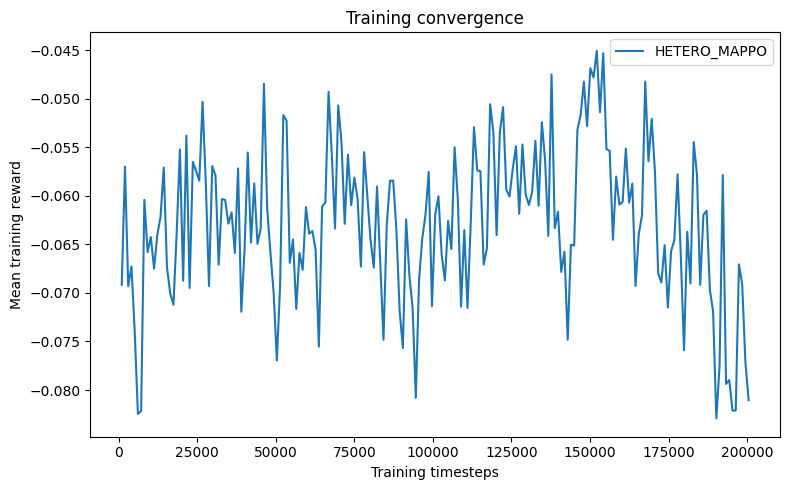

In [36]:
plot_training_histories(het_history)
plt.show()

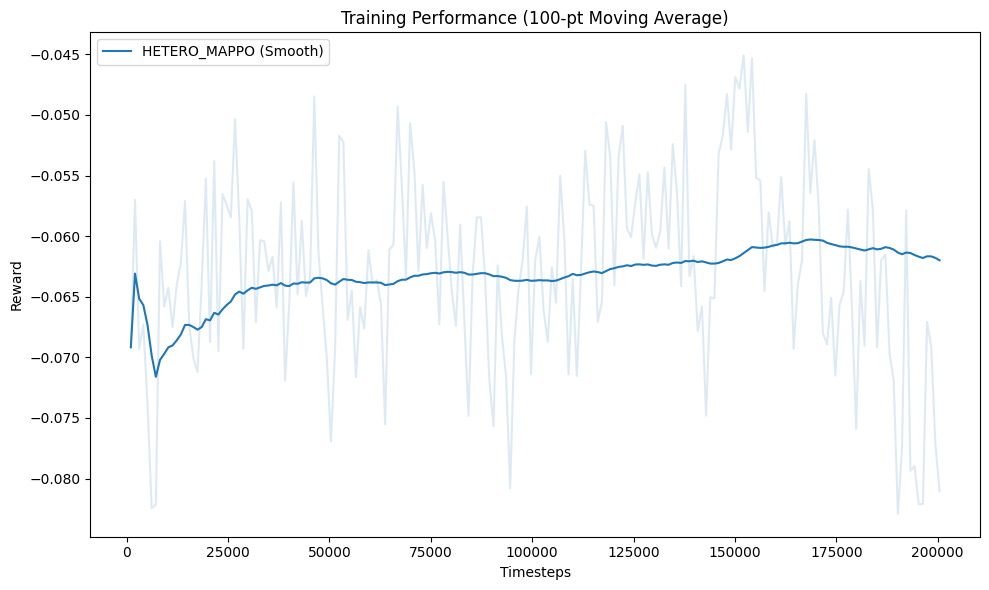

In [37]:
plot_moving_average_histories(het_history)
plt.show()

## Evaluate policies

The final comparison uses the same evaluation seeds for every policy.


In [38]:
def get_evaluation_results(policy):
    return evaluate_policy(
        config_file=paths.config_file,
        traffic_light_ids=traffic_light_ids,
        policy=policy,
        episodes=EVALUATION_EPISODES,
        max_steps=EPISODE_STEPS,
        seed=42,
        env_kwargs={
            "green_phase_count": GREEN_PHASE_COUNT,
            "min_green_seconds": MIN_GREEN_SECONDS,
            "seconds_per_action": SECONDS_PER_ACTION,
            "switch_penalty": SWITCH_PENALTY,
            "global_metric_interval": 10,
        },
    )

In [39]:
from marl_tsc.graph_based.heterogene.hetero_graph_builder import HeteroGraphBuilder
from marl_tsc.graph_based.heterogene.hetero_policy_adapter import HeteroGraphPolicyAdapter

topology = HeteroGraphBuilder(
    network_file=str(paths.network_file),
    intersection_obs_dim=23,  # from earlier print
    shared_dim=64,
    max_hops=3,
).build()

het_mappo_policy = HeteroGraphPolicyAdapter(
    graph_policy=het_model,
    topology=topology,
    policy_name="hetero_mappo",
)
get_evaluation_results(het_mappo_policy)

 Retrying in 1 seconds
 Retrying in 1 seconds
Finished Evaluation Episode 1/3 - Total Reward: -509.46
 Retrying in 1 seconds
 Retrying in 1 seconds
Finished Evaluation Episode 2/3 - Total Reward: -533.85
 Retrying in 1 seconds
 Retrying in 1 seconds
Finished Evaluation Episode 3/3 - Total Reward: -512.37


{'policy_name': 'hetero_mappo',
 'episodes': 3,
 'mean_total_reward': -518.5606666666686,
 'mean_local_queue': 0.3416259259259253,
 'mean_max_queue': 19.0,
 'total_completed_steps': 3000,
 'mean_switches_per_episode': 151.66666666666666,
 'mean_arrived_vehicles_per_episode': 661.6666666666666,
 'mean_waiting_time': 84.60074796539074,
 'mean_total_time_loss': 153505.72492936903,
 'mean_vehicle_count': 129.43333333333334}

In [ ]:
get_evaluation_results(zs_mappo_policy)

 Retrying in 1 seconds
 Retrying in 1 seconds


/content/marl-tsc/src/marl_tsc/graph_based/graph_policy_adapter.py:35: UserWarning: Creating a tensor from a list of numpy.ndarrays is extremely slow. Please consider converting the list to a single numpy.ndarray with numpy.array() before converting to a tensor. (Triggered internally at /pytorch/torch/csrc/utils/tensor_new.cpp:253.)
  x = torch.tensor(


Finished Evaluation Episode 1/3 - Total Reward: -165.60
 Retrying in 1 seconds
 Retrying in 1 seconds
Finished Evaluation Episode 2/3 - Total Reward: -166.44
 Retrying in 1 seconds
 Retrying in 1 seconds
Finished Evaluation Episode 3/3 - Total Reward: -166.36


{'policy_name': 'zs_mappo',
 'episodes': 3,
 'mean_total_reward': -166.1333333333333,
 'mean_local_queue': 0.2854861111111111,
 'mean_max_queue': 4.666666666666667,
 'total_completed_steps': 1800,
 'mean_switches_per_episode': 1032.0,
 'mean_arrived_vehicles_per_episode': 1465.0,
 'mean_waiting_time': 4.977860044294089,
 'mean_total_time_loss': 604.3309689134284,
 'mean_vehicle_count': 29.544444444444448}

In [ ]:
get_evaluation_results(pg_mappo_policy)

 Retrying in 1 seconds


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


 Retrying in 1 seconds


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


Finished Evaluation Episode 1/3 - Total Reward: -166.42
 Retrying in 1 seconds


...

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


 Retrying in 1 seconds


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


Finished Evaluation Episode 3/3 - Total Reward: -170.91


{'policy_name': 'pg_mappo',
 'episodes': 3,
 'mean_total_reward': -169.14666666666665,
 'mean_local_queue': 0.2826736111111111,
 'mean_max_queue': 5.666666666666667,
 'total_completed_steps': 1800,
 'mean_switches_per_episode': 1092.6666666666667,
 'mean_arrived_vehicles_per_episode': 1466.0,
 'mean_waiting_time': 4.713686172667246,
 'mean_total_time_loss': 591.8494346933018,
 'mean_vehicle_count': 29.366666666666664}

In [ ]:
get_evaluation_results(graph_mappo_policy)

 Retrying in 1 seconds


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


 Retrying in 1 seconds


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


Finished Evaluation Episode 1/3 - Total Reward: -167.56
 Retrying in 1 seconds


...

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


 Retrying in 1 seconds


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


Finished Evaluation Episode 3/3 - Total Reward: -170.92


{'policy_name': 'map_gat_mappo',
 'episodes': 3,
 'mean_total_reward': -169.09333333333336,
 'mean_local_queue': 0.27444444444444444,
 'mean_max_queue': 5.0,
 'total_completed_steps': 1800,
 'mean_switches_per_episode': 1149.3333333333333,
 'mean_arrived_vehicles_per_episode': 1464.0,
 'mean_waiting_time': 4.508162476308889,
 'mean_total_time_loss': 569.4936924167137,
 'mean_vehicle_count': 29.13888888888889}

In [ ]:
policies = {
    "Random": random_actions,
    "Fixed-Time": fixed_time_actions,
    "Shared PPO": ppo_model,
    "MAPPO": mappo_model,
    "Graph-MAPPO": graph_mappo_policy,
    "Public Goods Graph-Mappo": pg_mappo_policy,
    "Zero-Sum Graph-Mappo": zs_mappo_policy,
}

policy_results = {}

for name, policy in policies.items():
    print(f"Evaluating {name} model")
    policy_result = get_evaluation_results(policy)
    policy_results[name] = policy_result

Evaluating Random model
 Retrying in 1 seconds


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


 Retrying in 1 seconds


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


Finished Evaluation Episode 1/3 - Total Reward: -270.99
 Retrying in 1 seconds


...

Finished Evaluation Episode 2/3 - Total Reward: -166.44
 Retrying in 1 seconds


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


 Retrying in 1 seconds


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


Finished Evaluation Episode 3/3 - Total Reward: -166.36


In [ ]:
for name, result in policy_results.items():
    print(
        f"{name:10} "
        f"reward={result['mean_total_reward']:.1f}  "
        f"queue={result['mean_local_queue']:.3f}  "
        f"wait={result['mean_waiting_time']:.2f}"
    )

Random     reward=-268.9  queue=0.560  wait=12.86
Fixed-Time reward=-1689.3  queue=6.213  wait=141.22
Shared PPO reward=-146.5  queue=0.245  wait=3.80
MAPPO      reward=-134.3  queue=0.179  wait=2.03
Graph-MAPPO reward=-169.1  queue=0.274  wait=4.51
Public Goods Graph-Mappo reward=-169.1  queue=0.283  wait=4.71
Zero-Sum Graph-Mappo reward=-166.1  queue=0.285  wait=4.98


# Temporary Colab Start-up

In [1]:
#Colab start-up

import sys

IN_COLAB = 'google.colab' in sys.modules
COLAB = False

if IN_COLAB:
    print("Running inside Google Colab!")
    COLAB = True
else:
    print("Running in a local/different environment.")
if COLAB:
  #GITHUB --> COLAB CLONE / env setup
  import os
  from google.colab import userdata

  # 1. Get your access token
  token = userdata.get('GH_TOKEN')

  # 2. Clone the repo if it's not already there
  repo_path = '/content/marl-tsc'
  if not os.path.exists(repo_path):
      !git clone --branch main --single-branch https://{token}@github.com/abergh18/marl-tsc.git

  # 3. CRUCIAL: Move to the root directory
  # This ensures that 'import models' or 'import utils' works correctly
  %cd {repo_path}

  # 4. Install dependencies
  !pip install -r requirements.txt
if COLAB:
  !pip install eclipse-sumo libsumo

  import os
  os.environ["SUMO_HOME"] = "/usr/local/lib/python3.12/dist-packages/sumo"
  os.environ["PATH"] += ":/usr/local/lib/python3.12/dist-packages/sumo/bin"
from pathlib import Path
import sys
#Had to remove '.parent' for colab specific version
PROJECT_ROOT = Path.cwd().resolve()
SRC_DIR = PROJECT_ROOT / "src"

if str(SRC_DIR) not in sys.path:
    sys.path.insert(0, str(SRC_DIR))

if COLAB:
  from google.colab import drive
  drive.mount('/content/drive')
  OUTPUT_DIR = '/content/drive/MyDrive/Uni-Masters/Group Project/outputs'
else:
  OUTPUT_DIR = PROJECT_ROOT / "outputs"

Running inside Google Colab!
Cloning into 'marl-tsc'...
remote: Enumerating objects: 336, done.
remote: Counting objects: 100% (98/98), done.
remote: Compressing objects: 100% (42/42), done.
remote: Total 336 (delta 65), reused 66 (delta 53), pack-reused 238 (from 2)
Receiving objects: 100% (336/336), 2.91 MiB | 7.91 MiB/s, done.
Resolving deltas: 100% (149/149), done.
/content/marl-tsc
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 64.4/64.4 kB 4.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 805.5/805.5 kB 26.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 952.1/952.1 kB 63.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 138.4/138.4 kB 22.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 233.5/233.5 kB 28.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 50.2/50.2 kB 6.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 187.5/187.5 kB 24.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3

# Git Commit

Temporary: Just makes it easier when working on colab

In [ ]:
!git status


On branch main
Your branch and 'origin/main' have diverged,
and have 1 and 1 different commits each, respectively.
  (use "git pull" to merge the remote branch into yours)

nothing to commit, working tree clean


In [ ]:
!git add .

In [ ]:
import shlex
commit_msg = '''
Improved visualisation:
- Mph now calculated and displayed over khm
- Sumo/geographic layout improved, unclassified nodes now in place
TODO:
- Visual tweaks
- Needs to be network agnostic in terms of labeling
'''

In [ ]:
print(commit_msg)


Improved visualisation:
- Mph now calculated and displayed over khm
- Sumo/geographic layout improved, unclassified nodes now in place
TODO: 
- Visual tweaks
- Needs to be network agnostic in terms of labeling



In [ ]:
!git config --global user.email user_email
!git config --global user.name 'IsaacFayle-Waters'
!git commit -m {shlex.quote(commit_msg)}

On branch main
Your branch is ahead of 'origin/main' by 1 commit.
  (use "git push" to publish your local commits)

nothing to commit, working tree clean


In [ ]:
!git push origin main

To https://github.com/abergh18/marl-tsc.git
 ! [rejected]        main -> main (fetch first)
error: failed to push some refs to 'https://github.com/abergh18/marl-tsc.git'
hint: Updates were rejected because the remote contains work that you do
hint: not have locally. This is usually caused by another repository pushing
hint: to the same ref. You may want to first integrate the remote changes
hint: (e.g., 'git pull ...') before pushing again.
hint: See the 'Note about fast-forwards' in 'git push --help' for details.


In [ ]:
#!git pull origin main

From https://github.com/abergh18/marl-tsc
 * branch            main       -> FETCH_HEAD
hint: You have divergent branches and need to specify how to reconcile them.
hint: You can do so by running one of the following commands sometime before
hint: your next pull:
hint: 
hint:   git config pull.rebase false  # merge (the default strategy)
hint:   git config pull.rebase true   # rebase
hint:   git config pull.ff only       # fast-forward only
hint: 
hint: You can replace "git config" with "git config --global" to set a default
hint: preference for all repositories. You can also pass --rebase, --no-rebase,
hint: or --ff-only on the command line to override the configured default per
hint: invocation.
fatal: Need to specify how to reconcile divergent branches.


In [ ]:
#!git pull --rebase origin main

From https://github.com/abergh18/marl-tsc
 * branch            main       -> FETCH_HEAD
Successfully rebased and updated refs/heads/main.


In [ ]:
#!git push origin main

Enumerating objects: 7, done.
Counting objects: 100% (7/7), done.
Delta compression using up to 2 threads
Compressing objects: 100% (4/4), done.
Writing objects: 100% (4/4), 1.03 KiB | 1.03 MiB/s, done.
Total 4 (delta 3), reused 0 (delta 0), pack-reused 0
remote: Resolving deltas: 100% (3/3), completed with 3 local objects.
To https://github.com/abergh18/marl-tsc.git
   bc0dd98..f5f829c  main -> main
